In [1]:
#Importing Libraries
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
#load all files with city from filename
all_files = glob.glob('../data/raw/*.csv')
print(f"Total files found: {len(all_files)}")

# Map file prefixes to city names
prefix_to_city = {
    'DL': 'Delhi',
    'KA': 'Bengaluru',
    'MH': 'Mumbai',
    'TG': 'Hyderabad'
}

# Core pollutant columns we need
core_cols = [
    'From Date', 'PM2.5 (ug/m3)', 'PM10 (ug/m3)',
    'NO (ug/m3)', 'NO2 (ug/m3)', 'NOx (ppb)',
    'NH3 (ug/m3)', 'SO2 (ug/m3)', 'CO (mg/m3)',
    'Ozone (ug/m3)', 'Benzene (ug/m3)'
]

dfs = []

for f in all_files:
    filename = os.path.basename(f)   # e.g. DL001.csv
    prefix = filename[:2].upper()    # e.g. DL

    if prefix not in prefix_to_city:
        continue                     # skip other cities

    try:
        temp = pd.read_csv(f, low_memory=False)

        # Add city and station from filename
        temp['city'] = prefix_to_city[prefix]
        temp['station'] = filename.replace('.csv', '')

        # Keep only columns that exist in this file
        available = [c for c in core_cols if c in temp.columns]
        available += ['city', 'station']
        temp = temp[available]

        dfs.append(temp)

    except Exception as e:
        print(f"Error in {filename}: {e}")

df = pd.concat(dfs, ignore_index=True)
print(f"\n Data loaded successfully!")
print(f"Total rows: {df.shape[0]:,}")
print(f"Total columns: {df.shape[1]}")

Total files found: 454

 Data loaded successfully!
Total rows: 6,096,841
Total columns: 13


In [4]:
# Check City Distribution
print("City distribution:")
print(df['city'].value_counts())

print("\nStations per city:")
print(df.groupby('city')['station'].nunique())

City distribution:
city
Delhi        2796171
Mumbai       1536739
Bengaluru    1332059
Hyderabad     431872
Name: count, dtype: int64

Stations per city:
city
Bengaluru    39
Delhi        40
Hyderabad    14
Mumbai       41
Name: station, dtype: int64


In [5]:
# Clean and fix datetime
# Rename columns for cleanliness
df.rename(columns={
    'From Date': 'datetime',
    'PM2.5 (ug/m3)': 'PM25',
    'PM10 (ug/m3)': 'PM10',
    'NO (ug/m3)': 'NO',
    'NO2 (ug/m3)': 'NO2',
    'NOx (ppb)': 'NOx',
    'NH3 (ug/m3)': 'NH3',
    'SO2 (ug/m3)': 'SO2',
    'CO (mg/m3)': 'CO',
    'Ozone (ug/m3)': 'Ozone',
    'Benzene (ug/m3)': 'Benzene'
}, inplace=True)

# Convert datetime
df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')

# Drop rows where datetime is null
df = df.dropna(subset=['datetime'])

# Sort by city and datetime
df = df.sort_values(['city', 'datetime']).reset_index(drop=True)

print(f"Datetime fixed!")
print(f"Date range: {df['datetime'].min()} → {df['datetime'].max()}")
print(f"Total rows after cleaning: {df.shape[0]:,}")

Datetime fixed!
Date range: 2010-01-01 00:00:00 → 2023-03-31 23:00:00
Total rows after cleaning: 6,096,841


In [7]:
# Check missing values per city
print("Missing value % per column per city:\n")

for city in ['Delhi', 'Bengaluru', 'Mumbai', 'Hyderabad']:
    city_df = df[df['city'] == city]
    missing = (city_df.isnull().sum() / len(city_df) * 100).round(1)
    missing = missing.drop(['city', 'station', 'datetime'])
    print(f" {city} ({len(city_df):,} rows) ")
    print(missing)
    print()

Missing value % per column per city:

 Delhi (2,796,171 rows) 
PM25       33.6
PM10       41.8
NO         29.4
NO2        28.0
NOx        32.9
CO         38.3
Ozone      33.0
Benzene    47.9
SO2        41.5
NH3        48.9
dtype: float64

 Bengaluru (1,332,059 rows) 
PM25       41.1
PM10       41.8
NO         28.7
NO2        23.3
NOx        35.4
CO         36.3
Ozone      36.4
Benzene    58.5
SO2        25.3
NH3        42.8
dtype: float64

 Mumbai (1,536,739 rows) 
PM25       33.9
PM10       31.8
NO         32.9
NO2        33.0
NOx        27.4
CO         24.0
Ozone      34.2
Benzene    38.4
SO2        36.0
NH3        48.2
dtype: float64

 Hyderabad (431,872 rows) 
PM25       19.0
PM10       33.0
NO         11.5
NO2        11.8
NOx        10.0
CO         10.4
Ozone      14.6
Benzene    12.5
SO2        13.4
NH3        36.0
dtype: float64



/var/folders/5c/8z7vyvz92nv0y0r62jyssfnc0000gn/T/ipykernel_40999/3357578524.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(missing.index, rotation=45, ha='right')
/var/folders/5c/8z7vyvz92nv0y0r62jyssfnc0000gn/T/ipykernel_40999/3357578524.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(missing.index, rotation=45, ha='right')
/var/folders/5c/8z7vyvz92nv0y0r62jyssfnc0000gn/T/ipykernel_40999/3357578524.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(missing.index, rotation=45, ha='right')
/var/folders/5c/8z7vyvz92nv0y0r62jyssfnc0000gn/T/ipykernel_40999/3357578524.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks(

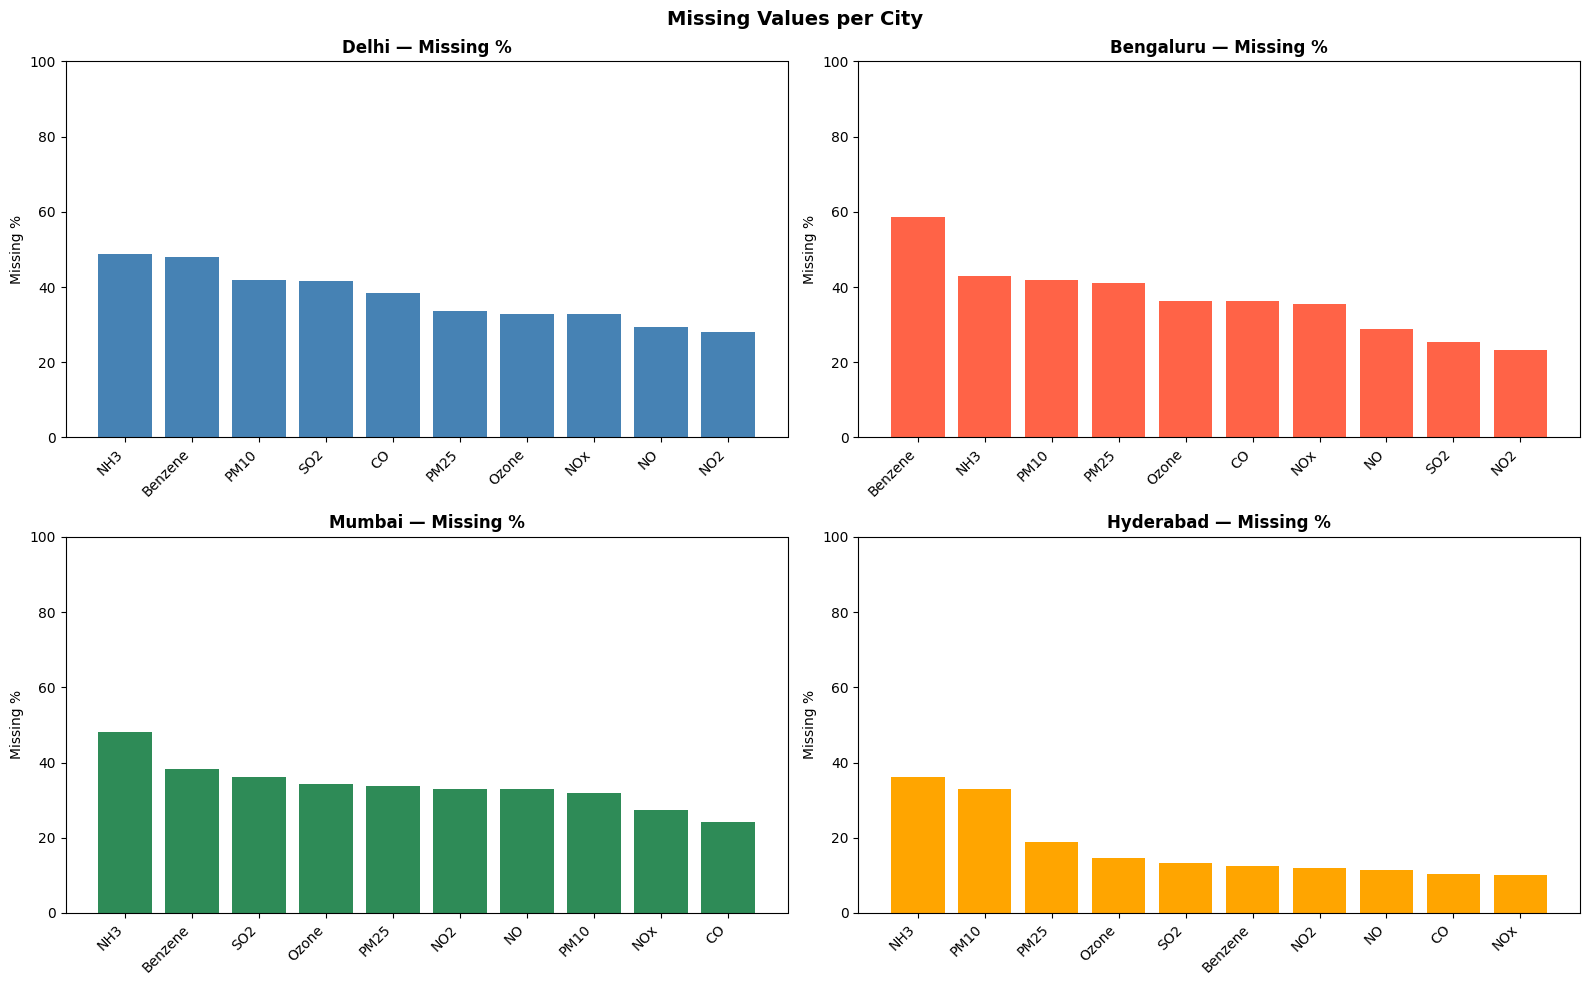

In [8]:
# Visualize missing values
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
cities = ['Delhi', 'Bengaluru', 'Mumbai', 'Hyderabad']
colors = ['steelblue', 'tomato', 'seagreen', 'orange']

for ax, city, color in zip(axes.flatten(), cities, colors):
    city_df = df[df['city'] == city]
    missing = (city_df.isnull().sum() / len(city_df) * 100)
    missing = missing.drop(['city', 'station', 'datetime']).sort_values(ascending=False)
    ax.bar(missing.index, missing.values, color=color)
    ax.set_title(f'{city} — Missing %', fontsize=12, fontweight='bold')
    ax.set_ylabel('Missing %')
    ax.set_ylim(0, 100)
    ax.set_xticklabels(missing.index, rotation=45, ha='right')

plt.suptitle('Missing Values per City', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

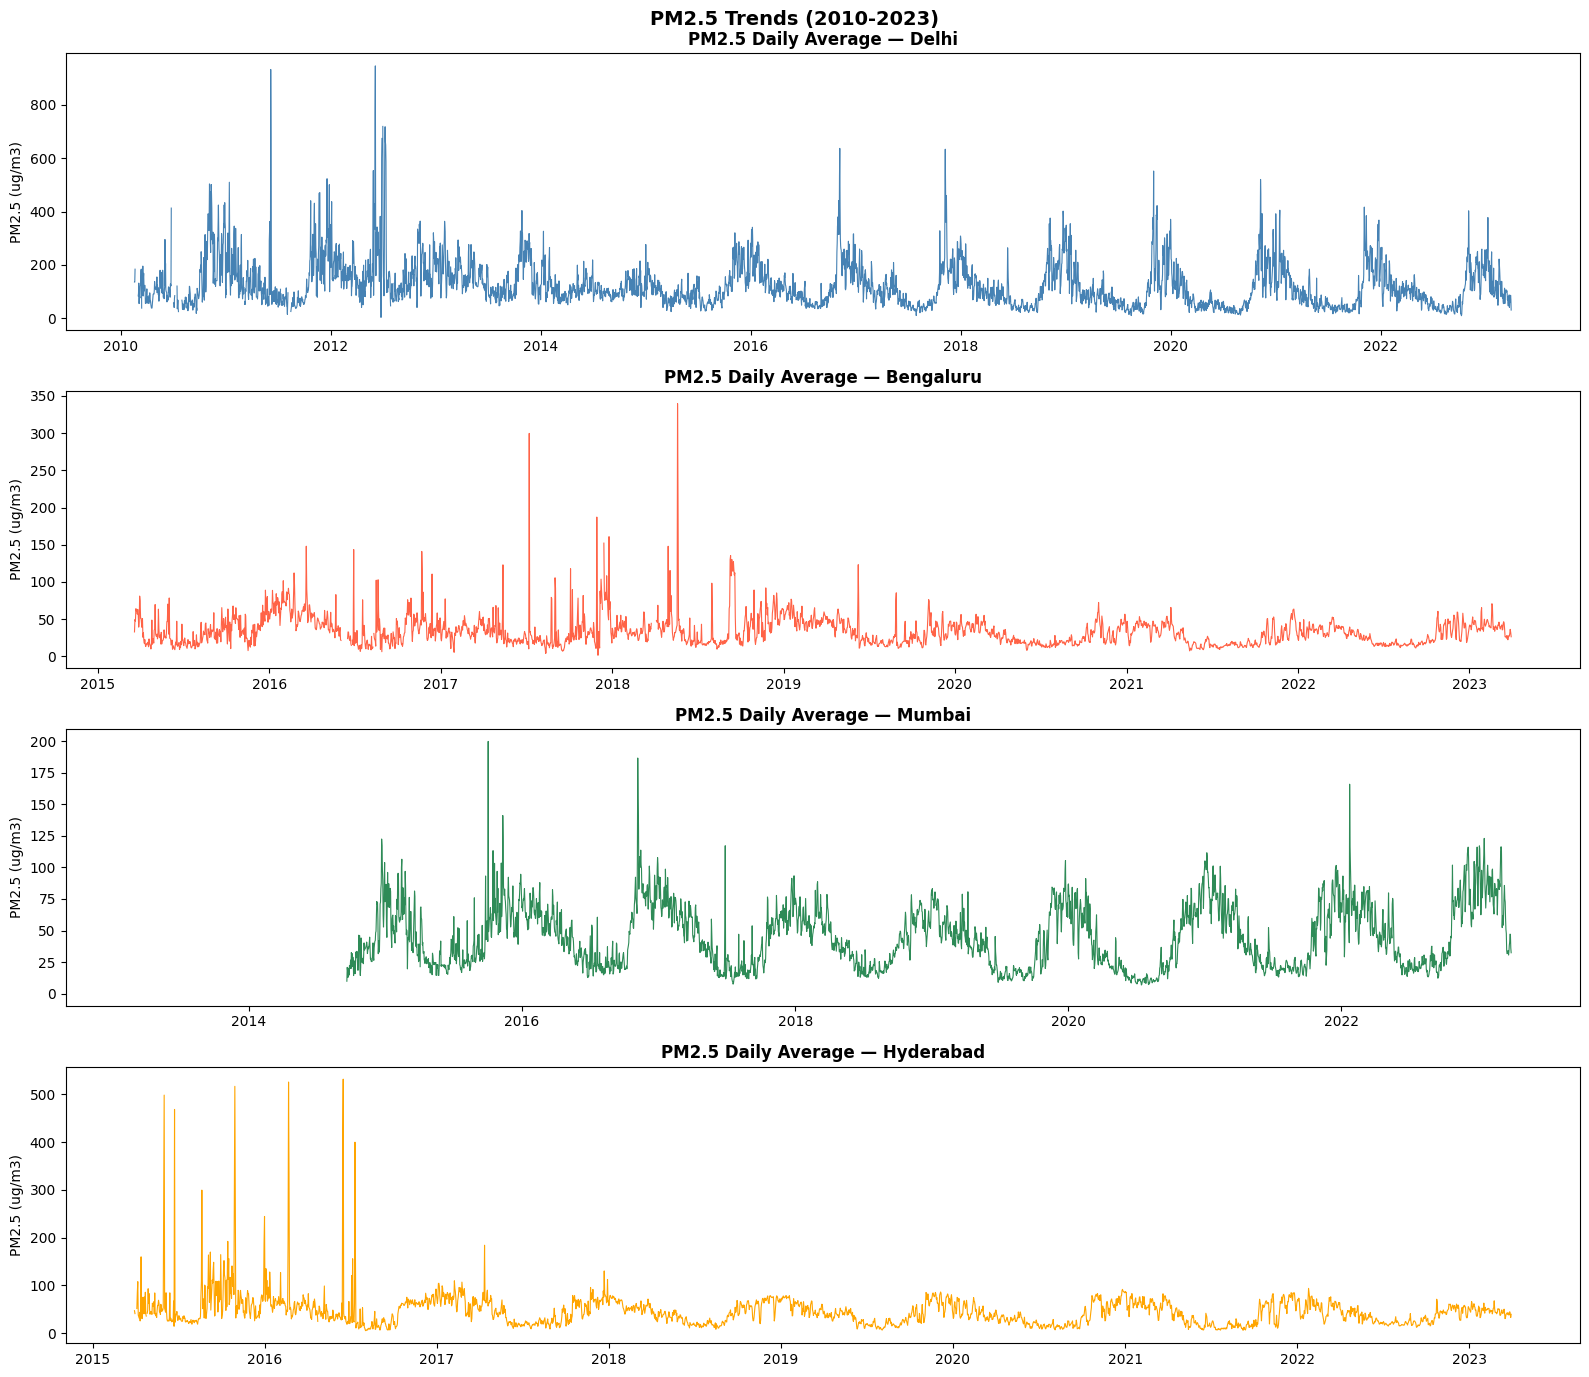

In [9]:
# Visualize PM2.5 trends
fig, axes = plt.subplots(4, 1, figsize=(16, 14))
cities = ['Delhi', 'Bengaluru', 'Mumbai', 'Hyderabad']
colors = ['steelblue', 'tomato', 'seagreen', 'orange']

for ax, city, color in zip(axes, cities, colors):
    city_df = df[df['city'] == city].copy()
    # Resample to daily average for cleaner plot
    daily = city_df.set_index('datetime')['PM25'].resample('D').mean()
    ax.plot(daily.index, daily.values, linewidth=0.8, color=color)
    ax.set_title(f'PM2.5 Daily Average — {city}', fontweight='bold')
    ax.set_ylabel('PM2.5 (ug/m3)')

plt.suptitle('PM2.5 Trends (2010-2023)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# Save Cleaned file
df.to_csv('../data/processed/four_cities_raw.csv', index=False)
print(f"Saved to data/processed/four_cities_raw.csv")
print(f"Final shape: {df.shape}")
print(f"\nPreview:")
print(df.head())

Saved to data/processed/four_cities_raw.csv
Final shape: (6096841, 13)

Preview:
             datetime  PM25  PM10    NO    NO2    NOx    CO  Ozone  Benzene  \
0 2010-01-01 00:00:00   NaN   NaN  3.51  17.84  21.26  0.48  25.30      NaN   
1 2010-01-01 00:00:00   NaN   NaN  0.85  21.07  21.91  0.45    NaN      NaN   
2 2010-01-01 01:00:00   NaN   NaN  5.57  14.71  20.28  0.49  29.90      NaN   
3 2010-01-01 01:00:00   NaN   NaN  1.19  20.41  21.60  0.35    NaN      NaN   
4 2010-01-01 02:00:00   NaN   NaN  5.69  14.18  19.87  0.38  34.11      NaN   

        city station   SO2    NH3  
0  Bengaluru   KA002  1.36    NaN  
1  Bengaluru   KA003  4.30  32.51  
2  Bengaluru   KA002  1.23    NaN  
3  Bengaluru   KA003  1.22  31.99  
4  Bengaluru   KA002  1.09    NaN  
